# Data Analytics Programming Project
## Phase 1: DATA PREPARATION AND CLEANING
### Team Members:
* LUBNA AL HAANI BINTI RADZUAN (A23CS0107)
* NAWWARAH AUNI BINTI NAZRUDIN (A23CS0143)
* NURUL IKA SYAFINY BINTI AZHAR (A23CS0164)
* NURAISYAH BINTI MOHD ZIKRE (A23CS0?)
* NAJMA SHAKIRAH BINTI SHAHRULZAMAN (A23CS0140)

### 1.0 Research Question
The primary research question for this phase is:

"How do different vehicle characteristics influence CO2 emissions, and how can we match 2025 car registration data with known emission factors to uncover meaningful insights?"

By analyzing vehicle fuel consumption and emission data, we aim to:

- Match 2025 registered car models with their 2014 fuel consumption and emission data.

- Identify vehicle categories with high CO2 emissions.

- Lay the foundation for visual and predictive analytics in the next phase.

### 2.0 Data Cleaning
In this step, we loaded the dataset and clean both dataset, includes standardize column name and remove duplicates. This step ensures that our data is reliable and suitable for deeper analytical operations.

We first import **pandas** library to handle and analyze the data and **.read_csv()** is used to load both datasets into the script.

In [121]:
import pandas as pd

# Load datasets
fuel_df = pd.read_csv("FuelConsumption.csv")
cars_df = pd.read_csv("cars_2025.csv")

Then, we use the **.columns** function to compare columns name in each dataframe. After we observed, column name "MAKE" in Fuel Consumption dataset does not match with the column named "maker" in Cars_2025 dataset. Additionally, we notice a difference in letter casing across both datasets (e.g., "MAKE" vs "maker").

Then, we use the **.isnull()** along with the **.sum()** functions to check for missing (null) values in each column of both DataFrames. **.isnull()** return boolean value where True is indicating whether the dataset contains null value and both datasets does not have null value since all return value is 0 which is False.

In [123]:
# Print all columns name in both dataset
print("Fuel Dataset Columns:", fuel_df.columns)
print("Cars Dataset Columns:", cars_df.columns)

# Check for missing values
print(fuel_df.isnull().sum())
print(cars_df.isnull().sum())

Fuel Dataset Columns: Index(['MODELYEAR', 'MAKE', 'MODEL', 'VEHICLECLASS', 'ENGINESIZE', 'CYLINDERS',
       'TRANSMISSION', 'FUELTYPE', 'FUELCONSUMPTION_CITY',
       'FUELCONSUMPTION_HWY', 'FUELCONSUMPTION_COMB',
       'FUELCONSUMPTION_COMB_MPG', 'CO2EMISSIONS'],
      dtype='object')
Cars Dataset Columns: Index(['date_reg', 'type', 'maker', 'model', 'colour', 'fuel', 'state'], dtype='object')
MODELYEAR                   0
MAKE                        0
MODEL                       0
VEHICLECLASS                0
ENGINESIZE                  0
CYLINDERS                   0
TRANSMISSION                0
FUELTYPE                    0
FUELCONSUMPTION_CITY        0
FUELCONSUMPTION_HWY         0
FUELCONSUMPTION_COMB        0
FUELCONSUMPTION_COMB_MPG    0
CO2EMISSIONS                0
dtype: int64
date_reg    0
type        0
maker       0
model       0
colour      0
fuel        0
state       0
dtype: int64


The **.columns.str.strip().str.lower().str.replace(" ", "_")** code contains a few diffent functions. First one is **.str.strip()** is to remove any whitespace from column names. Next, **.str.lower()** is used to change all column name to lowercase. Last but not least, **.str.replace()** is used to replace any spaces with "_" character to make all the column names is consistent.

Then, **.rename()** is used to change the "make" column name in fuel_consumption to "maker" to match with the other dataset.

**.dropna()** used to drop any row in each dataset with null value in maker and model columns.

Lastly, in this section, **.columns()** is used to check whether all column names needed for analyzation is matched and ready to use.

In [125]:
# Standardize column names
fuel_df.columns = fuel_df.columns.str.strip().str.lower().str.replace(" ", "_")
cars_df.columns = cars_df.columns.str.strip().str.lower().str.replace(" ", "_")

# Rename column 'make' in FuelConsumption to 'maker' to standardize with cars_2025
fuel_df.rename(columns={'make': 'maker'}, inplace=True)

# Drop rows with missing model or make
fuel_df.dropna(subset=['maker', 'model'], inplace=True)
cars_df.dropna(subset=['maker', 'model'], inplace=True)

print("Fuel Dataset Columns:", fuel_df.columns)
print("Cars Dataset Columns:", cars_df.columns)

Fuel Dataset Columns: Index(['modelyear', 'maker', 'model', 'vehicleclass', 'enginesize',
       'cylinders', 'transmission', 'fueltype', 'fuelconsumption_city',
       'fuelconsumption_hwy', 'fuelconsumption_comb',
       'fuelconsumption_comb_mpg', 'co2emissions'],
      dtype='object')
Cars Dataset Columns: Index(['date_reg', 'type', 'maker', 'model', 'colour', 'fuel', 'state'], dtype='object')


Same as the column names before but with loop, the data in each datasets are also cleaned by using **.str.lower()** function to change all data into lowercase and **.str.strip()** function to remove any unnecessary whitespaces.

**.head()** is used after standardize to check whether there are error with the replacement or the modification.

In [127]:
# Standardize data
for col in fuel_df.select_dtypes(include='object').columns:
    fuel_df[col] = fuel_df[col].str.lower().str.strip()

for col in cars_df.select_dtypes(include='object').columns:
    cars_df[col] = cars_df[col].str.lower().str.strip()

print("Fuel Consumption Data:")
display(fuel_df.head())

print("\nCars 2025 Data:")
display(cars_df.head())

Fuel Consumption Data:


,modelyear,maker,model,vehicleclass,enginesize,cylinders,transmission,fueltype,fuelconsumption_city,fuelconsumption_hwy,fuelconsumption_comb,fuelconsumption_comb_mpg,co2emissions
0,2014,acura,ilx,compact,2.0,4,as5,z,9.9,6.7,8.5,33,196
1,2014,acura,ilx,compact,2.4,4,m6,z,11.2,7.7,9.6,29,221
2,2014,acura,ilx hybrid,compact,1.5,4,av7,z,6.0,5.8,5.9,48,136
3,2014,acura,mdx 4wd,suv - small,3.5,6,as6,z,12.7,9.1,11.1,25,255
4,2014,acura,rdx awd,suv - small,3.5,6,as6,z,12.1,8.7,10.6,27,244



Cars 2025 Data:


,date_reg,type,maker,model,colour,fuel,state
0,2025-01-01,motokar,byd,seal,white,electric,rakan niaga
1,2025-01-01,window_van,cam,placer-x,yellow,greendiesel,johor
2,2025-01-01,jip,chery,jaecoo j7,green,petrol,rakan niaga
3,2025-01-01,jip,chery,jaecoo j7,silver,petrol,rakan niaga
4,2025-01-01,jip,chery,tiggo,grey,petrol,rakan niaga


Then, **.duplicated()** along with the **.sum()** function are used to check duplicates data and count the number of duplicates in each datasets. After run the code, we found 0 duplicate in fuel_consumption dataset while cars_2025 have as much as 215141 duplicates.

Hence, **.shape[]** function is used to show the total rows and **.drop_duplicated()** and **.shape[]** function used together to get the total of unique rows left if all the duplicates is removed. Then, **.drop_duplicates()** is used to drop all the duplicated rows and print "Duplicated rows are dropped" if dropping is successful.

In [129]:
# Check how many duplicate rows there are
print("Fuel duplicates:", fuel_df.duplicated().sum())
print("Cars duplicates:", cars_df.duplicated().sum())

# Show duplicate rows
# Check how many total rows and unique rows
print()
print("Duplicates in Cars_2025:")
print("Total rows:", cars_df.shape[0])
print("Unique rows:", cars_df.drop_duplicates().shape[0])

# Drop exact duplicate rows
cars_df.drop_duplicates(inplace=True)

print("Duplicated rows are dropped")

Fuel duplicates: 0
Cars duplicates: 215141

Duplicates in Cars_2025:
Total rows: 263578
Unique rows: 48437
Duplicated rows are dropped


Lastly for data cleaning, after cleaning is done, both datasets is exported into .csv using the **.to_csv()** function.

In [131]:
# Save cleaned data into new .csv files
cars_df.to_csv("cars_2025_cleaned.csv", index=False)
fuel_df.to_csv("fuel_consumption_cleaned.csv", index=False)

### 3.0 Data Wrangling & Preparation

In [133]:
# Merge datasets on 'maker' and 'model'
merged_df = pd.merge(cars_df, fuel_df, on=['maker', 'model'], how='right')

print("Merged Dataset:")
display(merged_df.head())

print("\nMerged shape:", merged_df.shape)

Merged Dataset:


,date_reg,type,maker,model,colour,fuel,state,modelyear,vehicleclass,enginesize,cylinders,transmission,fueltype,fuelconsumption_city,fuelconsumption_hwy,fuelconsumption_comb,fuelconsumption_comb_mpg,co2emissions
0,NaN,NaN,acura,ilx,NaN,NaN,NaN,2014,compact,2.0,4,as5,z,9.9,6.7,8.5,33,196
1,NaN,NaN,acura,ilx,NaN,NaN,NaN,2014,compact,2.4,4,m6,z,11.2,7.7,9.6,29,221
2,NaN,NaN,acura,ilx hybrid,NaN,NaN,NaN,2014,compact,1.5,4,av7,z,6.0,5.8,5.9,48,136
3,NaN,NaN,acura,mdx 4wd,NaN,NaN,NaN,2014,suv - small,3.5,6,as6,z,12.7,9.1,11.1,25,255
4,NaN,NaN,acura,rdx awd,NaN,NaN,NaN,2014,suv - small,3.5,6,as6,z,12.1,8.7,10.6,27,244



Merged shape: (10188, 18)


In [134]:
# Check for missing values
print("Missing values in merged dataset:")
print(merged_df.isnull().sum())

# Drop row with missing values
merged_df.dropna(inplace=True)

# Check how many duplicate rows there are
print("\nDuplicate rows in merged dataset:", merged_df.duplicated().sum())

print("\nFinal shape after cleaning:", merged_df.shape)

print("\nMerged Dataset:")
display(merged_df.head())

Missing values in merged dataset:
date_reg                    976
type                        976
maker                         0
model                         0
colour                      976
fuel                        976
state                       976
modelyear                     0
vehicleclass                  0
enginesize                    0
cylinders                     0
transmission                  0
fueltype                      0
fuelconsumption_city          0
fuelconsumption_hwy           0
fuelconsumption_comb          0
fuelconsumption_comb_mpg      0
co2emissions                  0
dtype: int64

Duplicate rows in merged dataset: 0

Final shape after cleaning: (9212, 18)

Merged Dataset:


,date_reg,type,maker,model,colour,fuel,state,modelyear,vehicleclass,enginesize,cylinders,transmission,fueltype,fuelconsumption_city,fuelconsumption_hwy,fuelconsumption_comb,fuelconsumption_comb_mpg,co2emissions
18,2025-04-22,motokar,aston martin,vanquish,green,petrol,w.p. kuala lumpur,2014,minicompact,5.9,12,a6,z,18.0,12.6,15.6,18,359
19,2025-03-06,motokar,audi,a4,silver,petrol,johor,2014,compact,2.0,4,av8,z,9.9,7.4,8.8,32,202
20,2025-03-06,motokar,audi,a4,black,petrol,pahang,2014,compact,2.0,4,av8,z,9.9,7.4,8.8,32,202
31,2025-01-31,motokar,audi,a8,grey,petrol,w.p. kuala lumpur,2014,mid-size,3.0,6,as8,z,13.1,8.8,11.2,25,258
32,2025-04-25,motokar,audi,a8,grey,petrol,w.p. kuala lumpur,2014,mid-size,3.0,6,as8,z,13.1,8.8,11.2,25,258


In [135]:
# Save the final cleaned and merged dataset
merged_df.to_csv("merged_cleaned_data.csv", index=False)
print("Merged and cleaned dataset saved to 'merged_cleaned_data.csv'")

Merged and cleaned dataset saved to 'merged_cleaned_data.csv'


Next, we prepare the dataset to fullfill the machine learning needs. Below is the steps for data preparation. We will import everthing we need first such as pandas, LabelEncoder and StandardScaler.

In [137]:
!pip install scikit-learn

In [138]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

First of all, we load the merged dataset from before.

In [140]:
# Load cleaned merged dataset
merged_df = pd.read_csv("merged_cleaned_data.csv")
print(merged_df)

        date_reg     type         maker     model  colour           fuel  \
0     2025-04-22  motokar  aston martin  vanquish   green         petrol   
1     2025-03-06  motokar          audi        a4  silver         petrol   
2     2025-03-06  motokar          audi        a4   black         petrol   
3     2025-01-31  motokar          audi        a8    grey         petrol   
4     2025-04-25  motokar          audi        a8    grey         petrol   
...          ...      ...           ...       ...     ...            ...   
9207  2025-04-30      jip         volvo      xc60   white  hybrid_petrol   
9208  2025-04-30      jip         volvo      xc60  silver  hybrid_petrol   
9209  2025-04-30      jip         volvo      xc60   black  hybrid_petrol   
9210  2025-04-30      jip         volvo      xc60   white  hybrid_petrol   
9211  2025-04-30      jip         volvo      xc60    blue  hybrid_petrol   

                  state  modelyear vehicleclass  enginesize  cylinders  \
0     w.p. ku

Then, we put the datasets into bins. The bins divide the co2emissions values into three intervals:

Low: 0 to 150

Medium: 150 to 200

High: above 200

The pd.cut() function is used to map each vehicle's co2emissions value to a corresponding emission class based on the defined bins and labels. A new column called 'emission_class' is added to the DataFrame merged_df, containing the label ('low', 'medium', or 'high') for each vehicle. Then, we display the updated DataFrame so we can verify that the emission_class column has been correctly added and labeled.

In [142]:
# Step 1: Create emission class (target labels)
bins = [0, 150, 200, float('inf')]
labels = ['low', 'medium', 'high']
merged_df['emission_class'] = pd.cut(merged_df['co2emissions'], bins=bins, labels=labels)
print(merged_df)

        date_reg     type         maker     model  colour           fuel  \
0     2025-04-22  motokar  aston martin  vanquish   green         petrol   
1     2025-03-06  motokar          audi        a4  silver         petrol   
2     2025-03-06  motokar          audi        a4   black         petrol   
3     2025-01-31  motokar          audi        a8    grey         petrol   
4     2025-04-25  motokar          audi        a8    grey         petrol   
...          ...      ...           ...       ...     ...            ...   
9207  2025-04-30      jip         volvo      xc60   white  hybrid_petrol   
9208  2025-04-30      jip         volvo      xc60  silver  hybrid_petrol   
9209  2025-04-30      jip         volvo      xc60   black  hybrid_petrol   
9210  2025-04-30      jip         volvo      xc60   white  hybrid_petrol   
9211  2025-04-30      jip         volvo      xc60    blue  hybrid_petrol   

                  state  modelyear vehicleclass  enginesize  cylinders  \
0     w.p. ku


This step is essential for supervised machine learning tasks where CO₂ emissions need to be predicted or analyzed in categories rather than as continuous numerical values. It converts a regression problem into a classification problem.


The next step is dropping unncecessary collumn. We will create a new DataFrame X, which contains the independent variables (features) used to predict the emission class. It removes the following columns from the dataset:

'model': This is likely a very specific identifier for each vehicle (e.g., "Toyota Camry LE"), which can lead to overfitting and doesn't generalize well for prediction.

'co2emissions': This numeric column was used to create the emission_class label. Keeping it would be data leakage, as it directly contains the information you're trying to predict.

'emission_class': This is the target label, so it is excluded from the features.

The we created a y that stores the dependent variable (target), which is the categorical class label ('low', 'medium', 'high') created in Step 1. This will be used during model training to learn the relationship between the features in X and the emission class. Then, we print both X and y to shows the feature set to verify that only the relevant columns remain for training the model.

In [144]:
# Step 2: Drop columns not needed
# - Drop `model` (too specific)
# - Drop `co2_emissions_g/km` (we've created categorical label)
# - Keep `maker`
X = merged_df.drop(columns=['model', 'co2emissions', 'emission_class'])
y = merged_df['emission_class']
print(X)

        date_reg     type         maker  colour           fuel  \
0     2025-04-22  motokar  aston martin   green         petrol   
1     2025-03-06  motokar          audi  silver         petrol   
2     2025-03-06  motokar          audi   black         petrol   
3     2025-01-31  motokar          audi    grey         petrol   
4     2025-04-25  motokar          audi    grey         petrol   
...          ...      ...           ...     ...            ...   
9207  2025-04-30      jip         volvo   white  hybrid_petrol   
9208  2025-04-30      jip         volvo  silver  hybrid_petrol   
9209  2025-04-30      jip         volvo   black  hybrid_petrol   
9210  2025-04-30      jip         volvo   white  hybrid_petrol   
9211  2025-04-30      jip         volvo    blue  hybrid_petrol   

                  state  modelyear vehicleclass  enginesize  cylinders  \
0     w.p. kuala lumpur       2014  minicompact         5.9         12   
1                 johor       2014      compact         2.0

In [145]:
print(y)

0       high
1       high
2       high
3       high
4       high
        ... 
9207    high
9208    high
9209    high
9210    high
9211    high
Name: emission_class, Length: 9212, dtype: category
Categories (3, object): ['low' < 'medium' < 'high']


This preprocessing step ensures that the dataset only contains useful and generalizable information for training the model. Removing irrelevant or problematic columns improves model performance and reduces the risk of overfitting or data leakage.


Then, we encode the 'maker' collumn. This step transforms the categorical feature 'maker' (e.g., Toyota, Honda, Ford) into numerical values so it can be used by machine learning models, which generally require numerical input. Firstly, we creates an instance of LabelEncoder from sklearn.preprocessing. LabelEncoder converts text labels into integer values, assigning a unique number to each category. This line applies the label encoding to the 'maker' column in the feature set X. For example:

'Toyota' might be encoded as 3

'Honda' as 1

'Ford' as 0, etc.

The encoder assigns integer labels alphabetically by default. Then, we print the merged_df.

In [147]:
# Step 3: Encode 'maker' with LabelEncoder
le_maker = LabelEncoder()
X['maker'] = le_maker.fit_transform(X['maker'])
print(merged_df)

        date_reg     type         maker     model  colour           fuel  \
0     2025-04-22  motokar  aston martin  vanquish   green         petrol   
1     2025-03-06  motokar          audi        a4  silver         petrol   
2     2025-03-06  motokar          audi        a4   black         petrol   
3     2025-01-31  motokar          audi        a8    grey         petrol   
4     2025-04-25  motokar          audi        a8    grey         petrol   
...          ...      ...           ...       ...     ...            ...   
9207  2025-04-30      jip         volvo      xc60   white  hybrid_petrol   
9208  2025-04-30      jip         volvo      xc60  silver  hybrid_petrol   
9209  2025-04-30      jip         volvo      xc60   black  hybrid_petrol   
9210  2025-04-30      jip         volvo      xc60   white  hybrid_petrol   
9211  2025-04-30      jip         volvo      xc60    blue  hybrid_petrol   

                  state  modelyear vehicleclass  enginesize  cylinders  \
0     w.p. ku

This step is important since machine learning algorithms cannot process string labels directly. By encoding the 'maker' column into numbers, this step makes the data machine-readable and ready for model training.

The last step is we encode the remaining categorical collumns. This step ensures that all remaining categorical (text) columns in the feature set X are converted into numerical values using label encoding. First, we selects all columns in X that have the data type 'object', which usually indicates string values. Examples might include:

'transmission' (e.g., 'Automatic', 'Manual')

'fuel_type' (e.g., 'Petrol', 'Diesel', 'Electric')

For each of these text-based columns, LabelEncoder is applied to convert the string categories into unique integers. For example:

'Automatic' → 0, 'Manual' → 1

'Petrol' → 2, 'Diesel' → 0, 'Electric' → 1 (alphabetical order)

Then, we print the merged_df

In [149]:
# Step 4: Encode any other categorical columns (e.g., transmission, fuel_type)
for col in X.select_dtypes(include='object').columns:
    X[col] = LabelEncoder().fit_transform(X[col])
print(merged_df)

        date_reg     type         maker     model  colour           fuel  \
0     2025-04-22  motokar  aston martin  vanquish   green         petrol   
1     2025-03-06  motokar          audi        a4  silver         petrol   
2     2025-03-06  motokar          audi        a4   black         petrol   
3     2025-01-31  motokar          audi        a8    grey         petrol   
4     2025-04-25  motokar          audi        a8    grey         petrol   
...          ...      ...           ...       ...     ...            ...   
9207  2025-04-30      jip         volvo      xc60   white  hybrid_petrol   
9208  2025-04-30      jip         volvo      xc60  silver  hybrid_petrol   
9209  2025-04-30      jip         volvo      xc60   black  hybrid_petrol   
9210  2025-04-30      jip         volvo      xc60   white  hybrid_petrol   
9211  2025-04-30      jip         volvo      xc60    blue  hybrid_petrol   

                  state  modelyear vehicleclass  enginesize  cylinders  \
0     w.p. ku

This step ensures all categorical features are numeric, which is a requirement for most machine learning models. It generalizes the encoding step from Step 3 (which was only for 'maker') to apply automatically to any remaining object-type columns.

### Data Aggregation and Group Operations
After cleaning and merging, we:

Grouped data by vehicle make, model, and fuel type.

Aggregated values like average CO2 emissions, average fuel consumption, and count of registrations.

Identified top and bottom emitters by averaging across categories.

These operations help in uncovering trends and setting up comparison benchmarks for emission analysis.

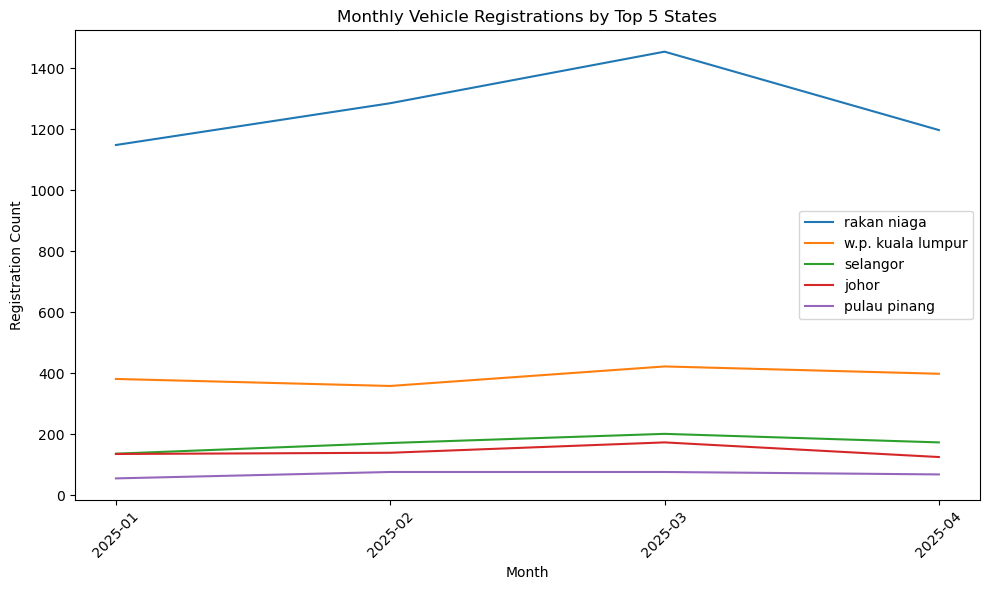

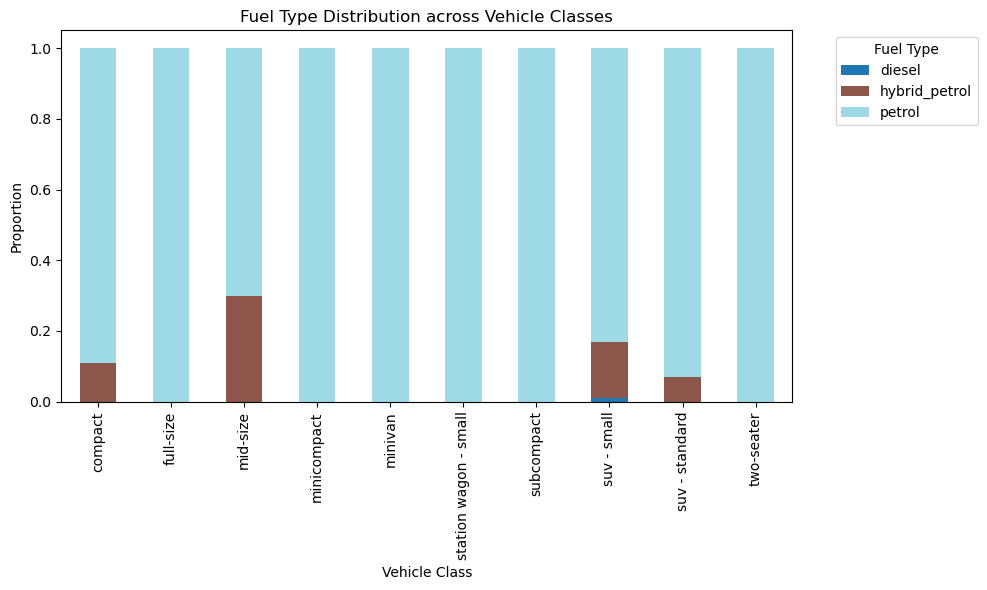

In [152]:
import pandas as pd
import matplotlib.pyplot as plt

# === Load and Prepare the Dataset ===
df = pd.read_csv('merged_cleaned_data.csv')
df['date_reg'] = pd.to_datetime(df['date_reg'], errors='coerce')
df['reg_month'] = df['date_reg'].dt.to_period('M')

# === Get Top 5 States by Registration Count ===
top5_states = (
    df['state']
    .value_counts()
    .head(5)
)
top_states_list = top5_states.index.tolist()

# === Filter Data for Top 5 States Only ===
df_top_states = df[df['state'].isin(top_states_list)]

# === Monthly Registration Trend for Top 5 States ===
df_top_states.loc[:, 'reg_month'] = df_top_states['date_reg'].dt.to_period('M')

monthly_by_state = (
    df_top_states.groupby(['reg_month', 'state'])
    .size()
    .reset_index(name='registration_count')
    .sort_values('reg_month')
)

# === Plot: Line Plot for Monthly Registrations per Top State ===
plt.figure(figsize=(10, 6))
for state in top_states_list:
    data = monthly_by_state[monthly_by_state['state'] == state]
    plt.plot(data['reg_month'].astype(str), data['registration_count'], label=state)

plt.xlabel('Month')
plt.ylabel('Registration Count')
plt.title('Monthly Vehicle Registrations by Top 5 States')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# === Cross-tab of Vehicle Class and Fuel Type ===
vehicle_fuel_crosstab = pd.crosstab(df['vehicleclass'], df['fuel'])

# === Normalize to Percentage for Better Insight ===
vehicle_fuel_pct = vehicle_fuel_crosstab.div(vehicle_fuel_crosstab.sum(axis=1), axis=0).round(2)

# === Plot: Stacked Bar Chart ===
vehicle_fuel_pct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='tab20')
plt.title('Fuel Type Distribution across Vehicle Classes')
plt.xlabel('Vehicle Class')
plt.ylabel('Proportion')
plt.legend(title='Fuel Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 4. Conclusion for Phase 1
Phase 1 focused on preparing and integrating datasets to ensure accuracy in analysis. Key outcomes include:

A successfully cleaned and merged dataset of 2025 vehicle registrations with 2014 emission data.

Structured data that allows for meaningful group operations and aggregation.

Insights into which vehicle groups contribute most to emissions, setting the stage for visual analytics and predictive modeling in Phase 2.

This foundational work enables effective data-driven decision-making.